In [2]:
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,recall_score,f1_score,confusion_matrix,precision_score,roc_curve,roc_auc_score
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,StackingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [3]:
df=pd.read_csv('C:/Users/DHARSHINI/Downloads/sem5/machine-learning/experimemt-6/datasets/wdbc.data',header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
def EDA(df):
    print("Shape : ",df.shape)
    print("\n\nColumns  : ",df.columns)
    print("\n\nInfo : ",df.info())
    print("\n\nDescribe : ",df.describe())
    print("\n\nNull Total : ",df.isnull().sum().sum())
    print("Target variable Unique values : ",df[1].unique())
    print("\n",df[1].value_counts())

In [5]:
def histogram(col):
    plt.figure(figsize=(5,5))
    df[col].hist()
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()

In [6]:
def outliers_detection(col):
    plt.figure(figsize=(5,5))
    sns.boxplot(x=df[col])
    plt.xlabel(col)
    plt.show()

In [7]:
def corr_analysis(df):
    plt.figure(figsize=(15,15))
    sns.heatmap(df.corr(),cmap="coolwarm")
    plt.show()

In [8]:
def label_encoding(df):
    col = df[1].unique()

    df[1]=df[1].map({
        col[0]: 1,
        col[1]: 0
    })

    return df

Shape :  (569, 32)


Columns  :  Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
      dtype='int64')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       569 non-null    int64  
 1   1       569 non-null    object 
 2   2       569 non-null    float64
 3   3       569 non-null    float64
 4   4       569 non-null    float64
 5   5       569 non-null    float64
 6   6       569 non-null    float64
 7   7       569 non-null    float64
 8   8       569 non-null    float64
 9   9       569 non-null    float64
 10  10      569 non-null    float64
 11  11      569 non-null    float64
 12  12      569 non-null    float64
 13  13      569 non-null    float64
 14  14      569 non-null    float64
 15  15      569 non-null    float64
 16  16      569 non-null    flo

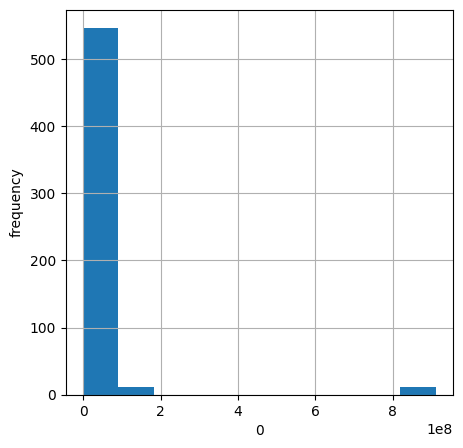

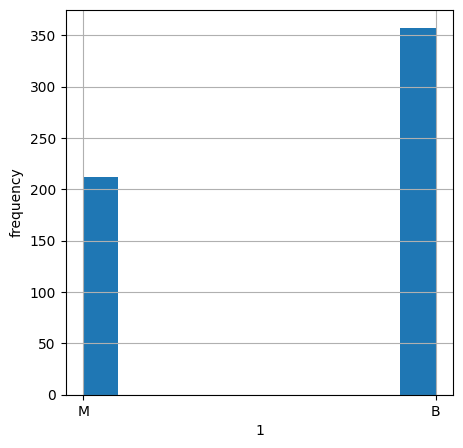

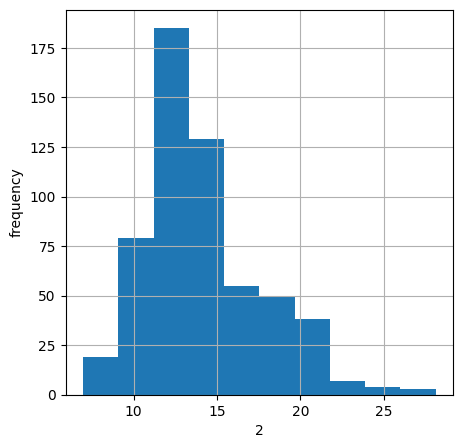

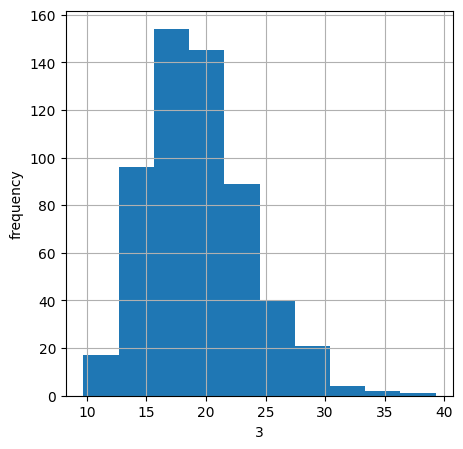

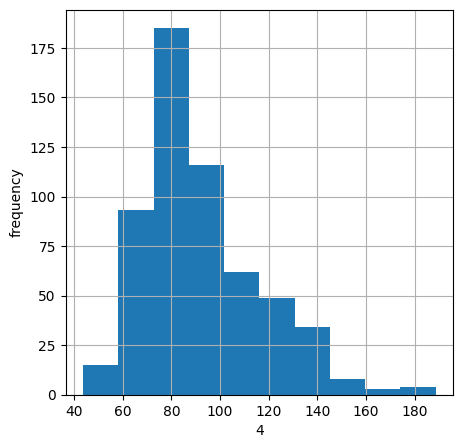

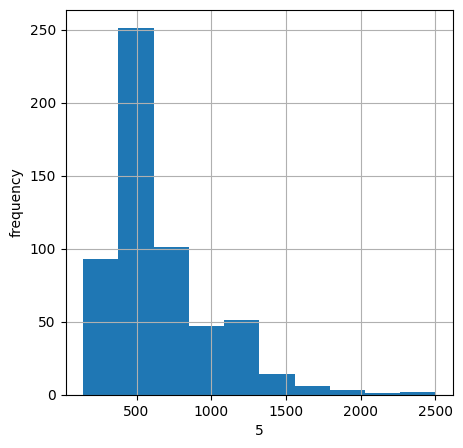

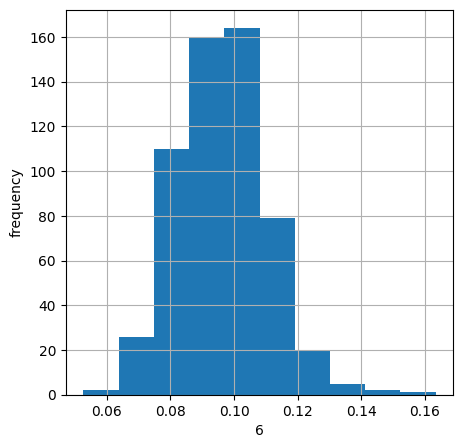

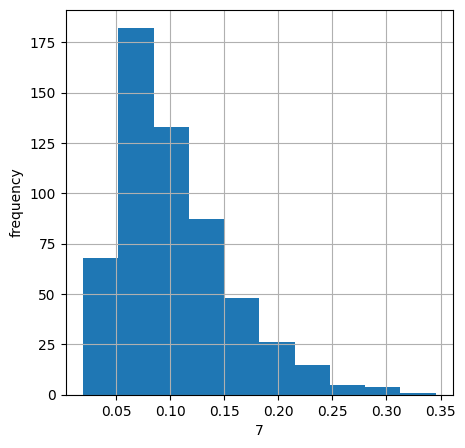

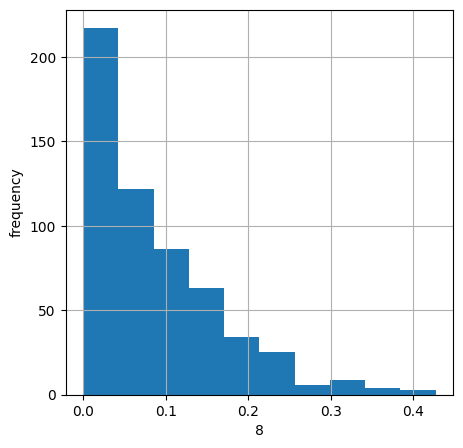

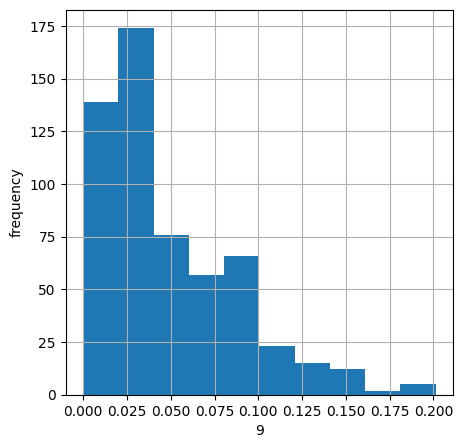

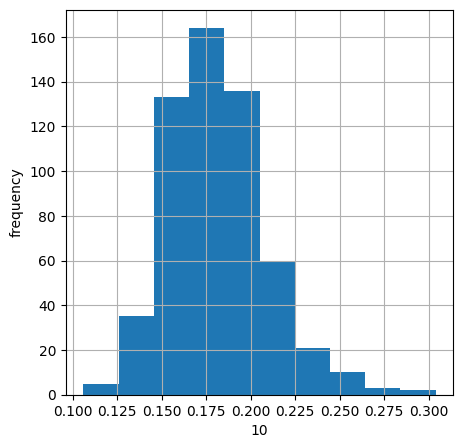

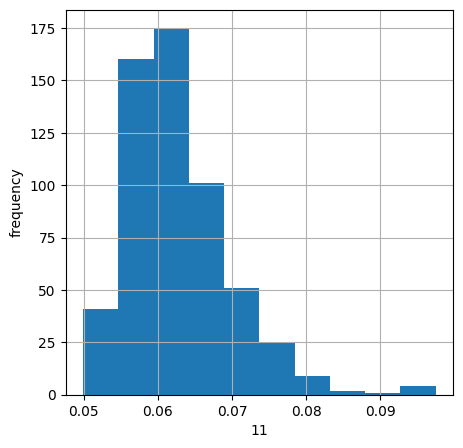

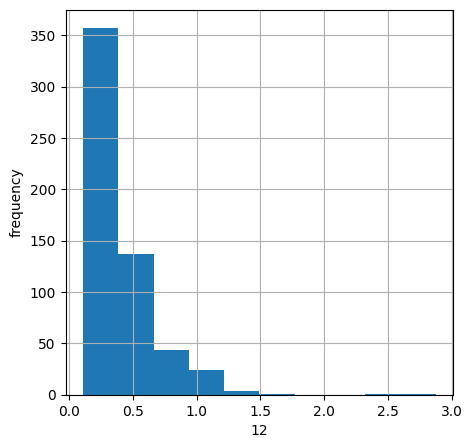

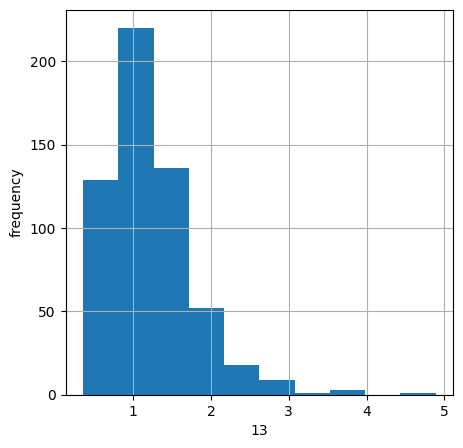

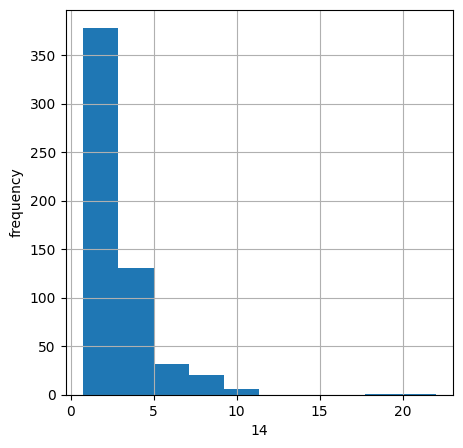

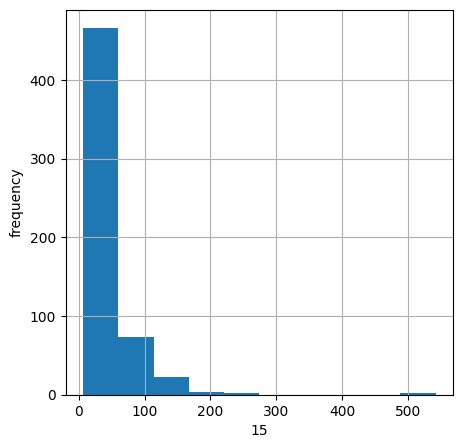

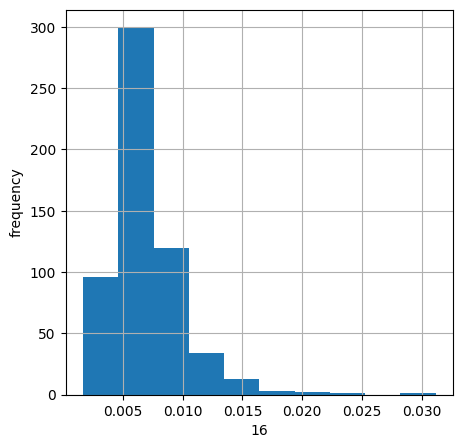

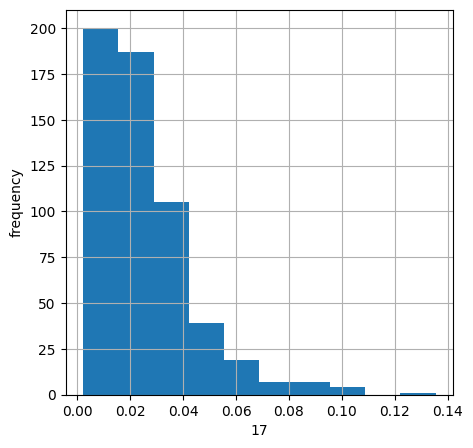

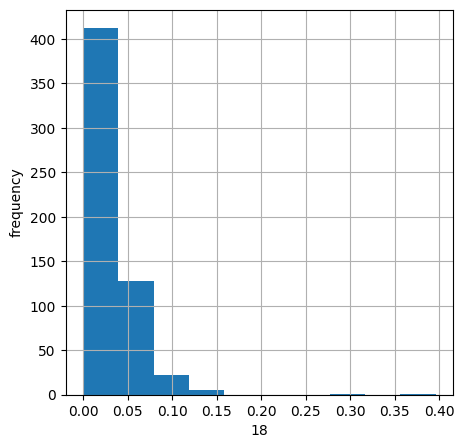

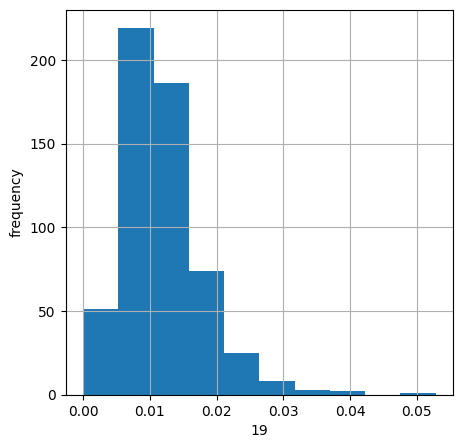

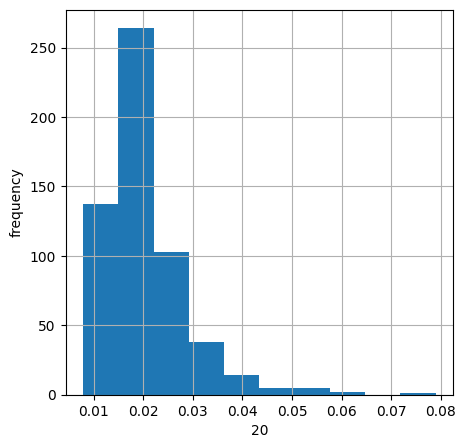

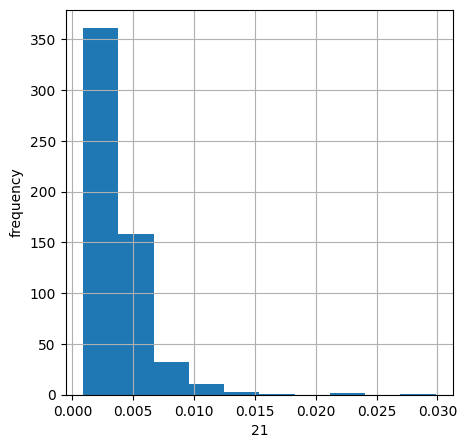

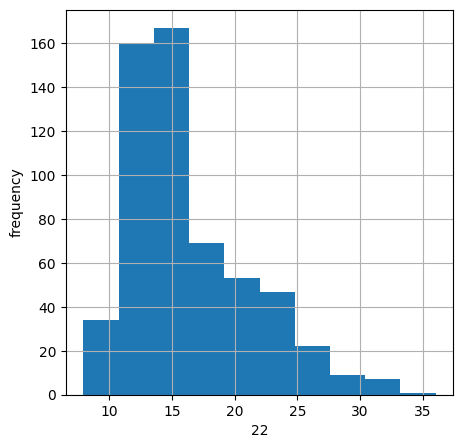

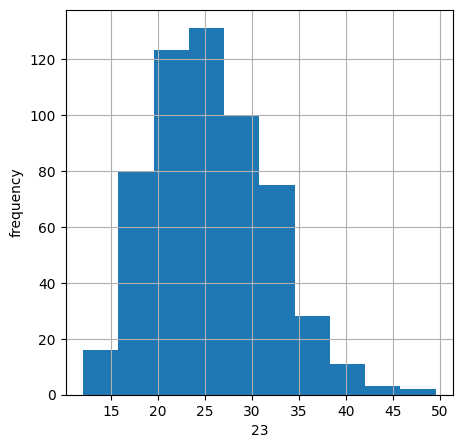

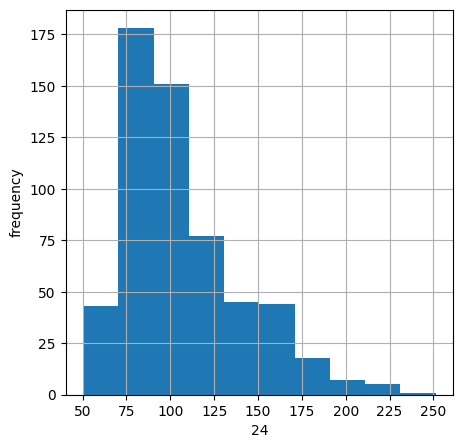

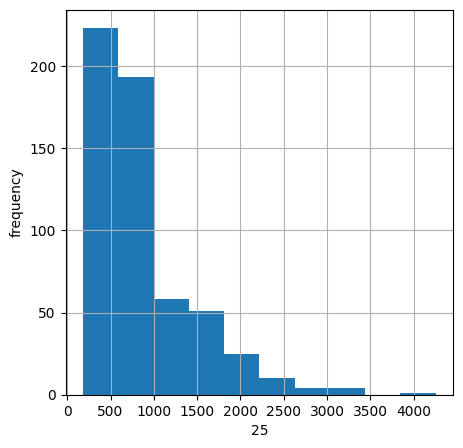

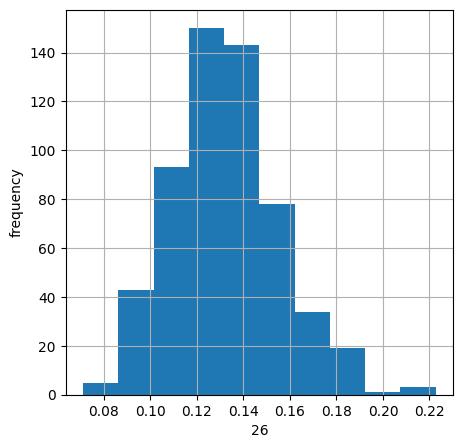

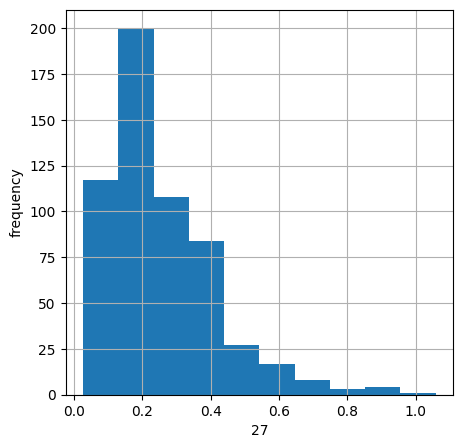

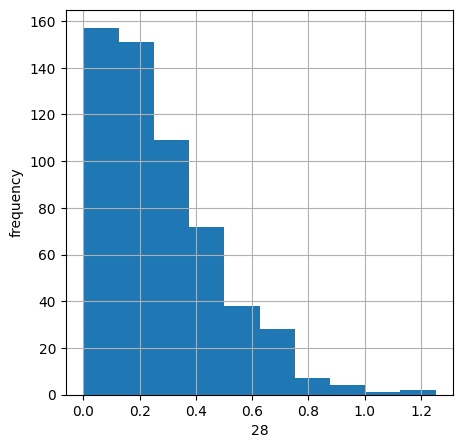

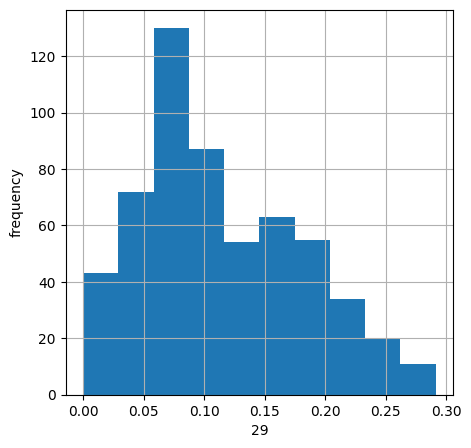

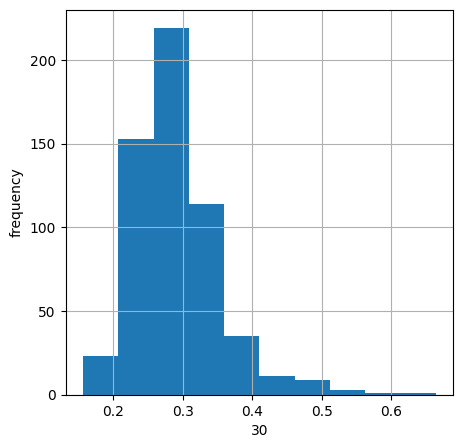

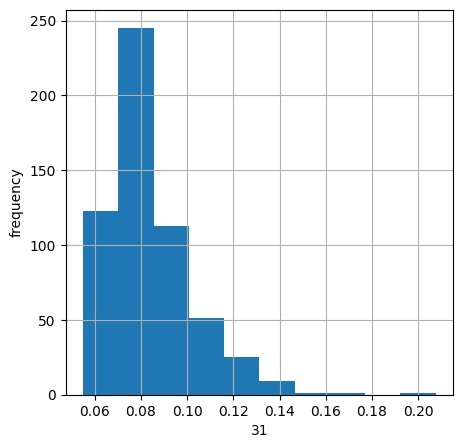

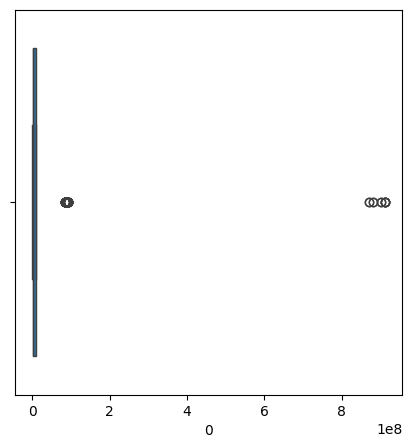

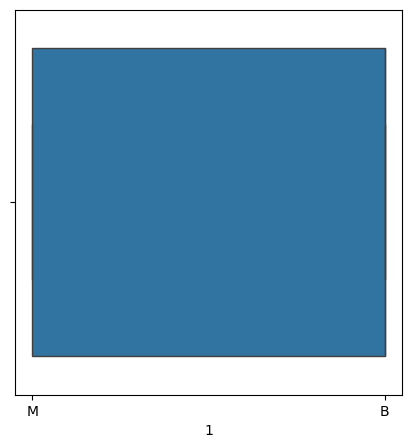

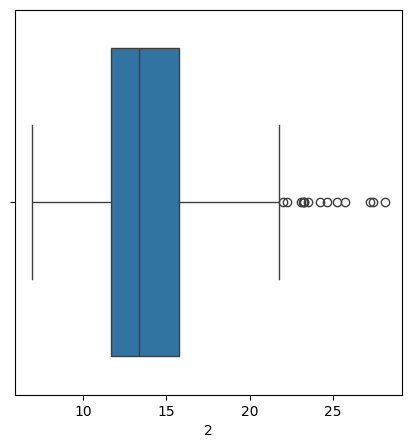

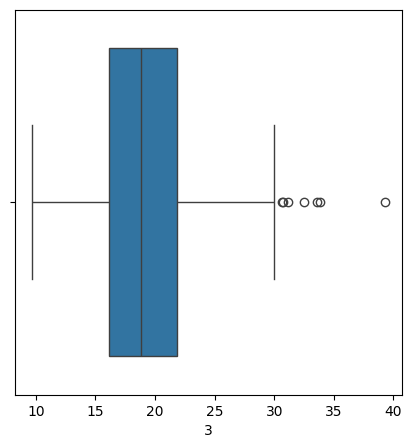

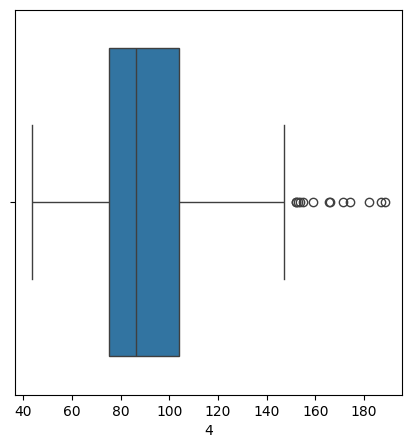

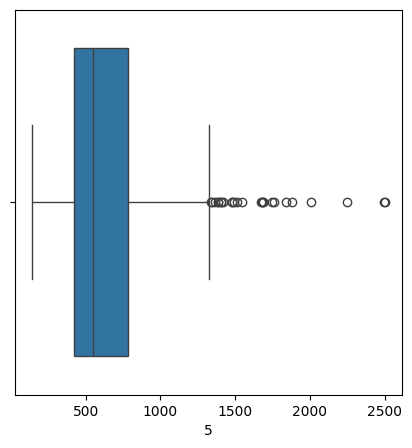

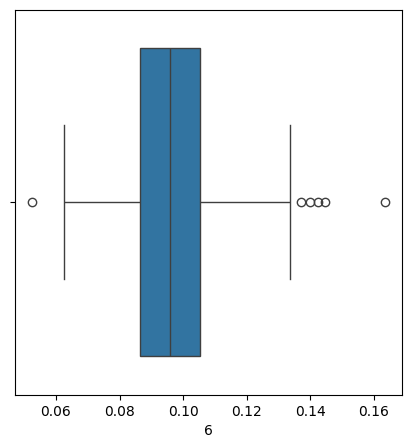

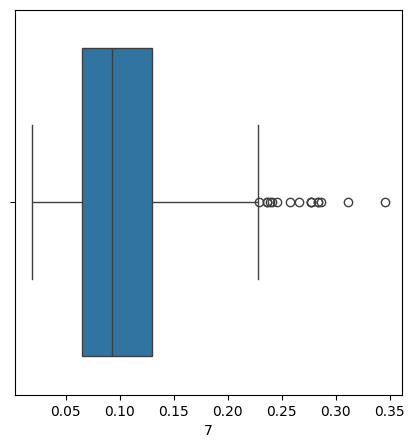

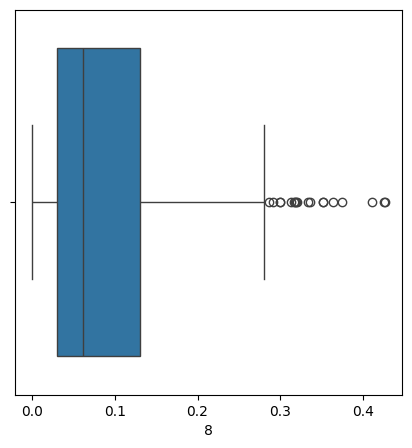

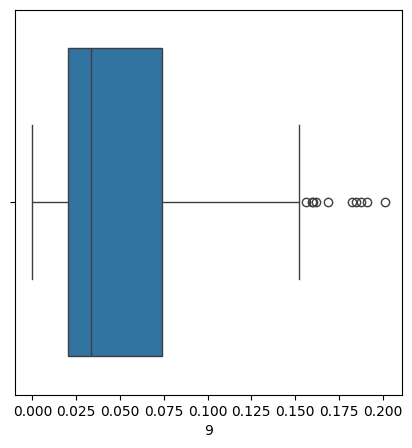

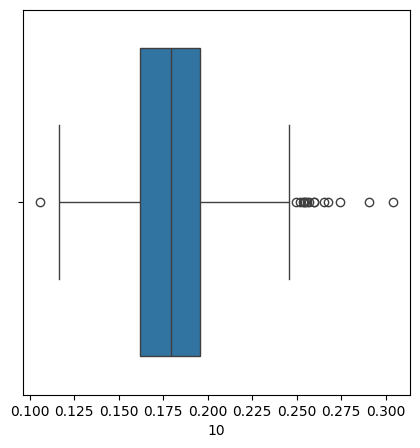

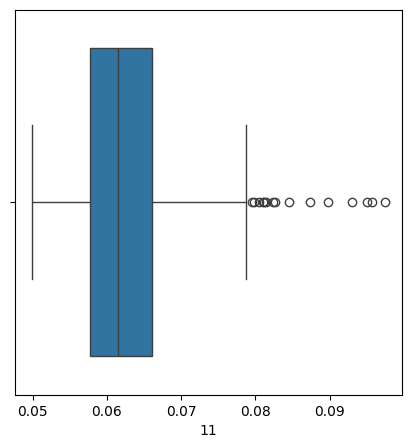

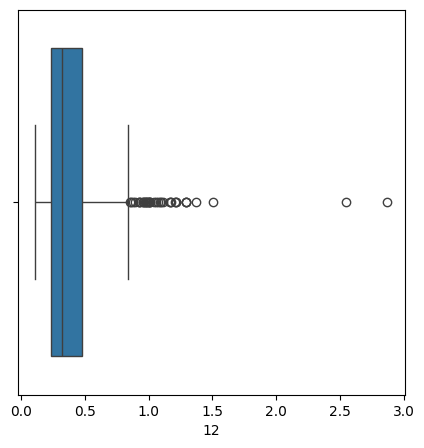

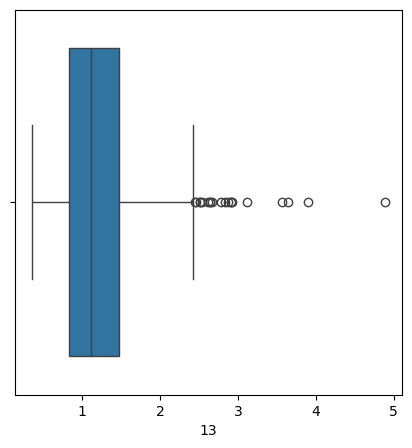

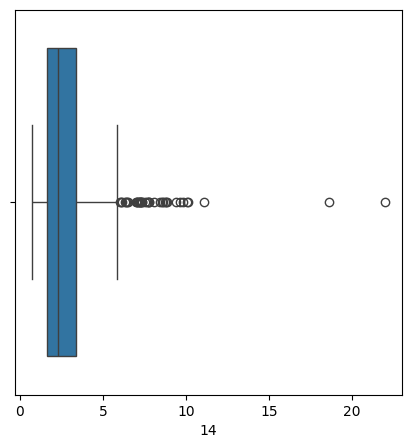

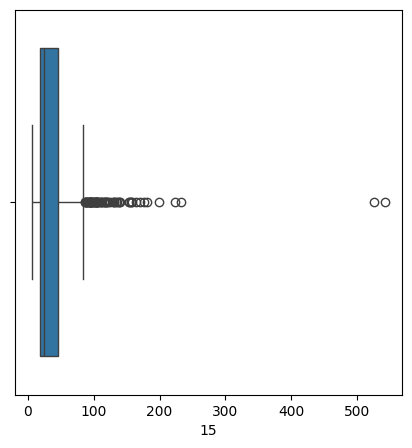

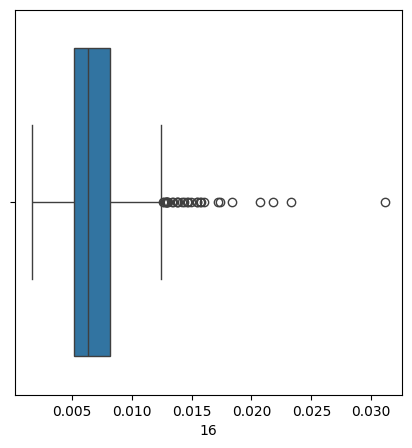

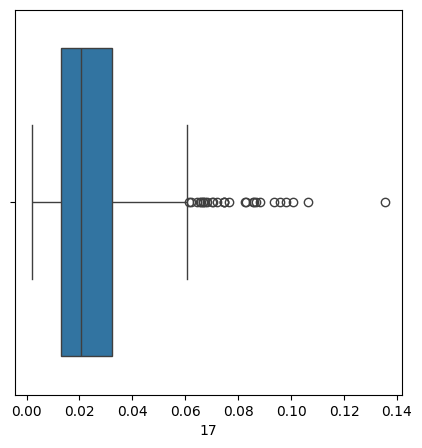

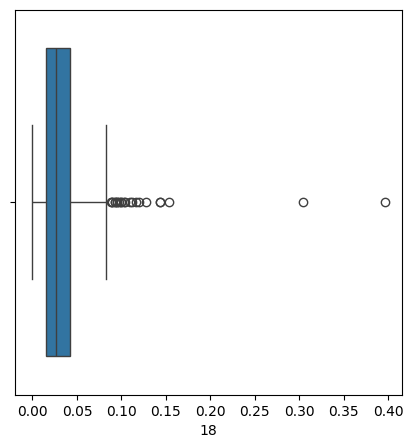

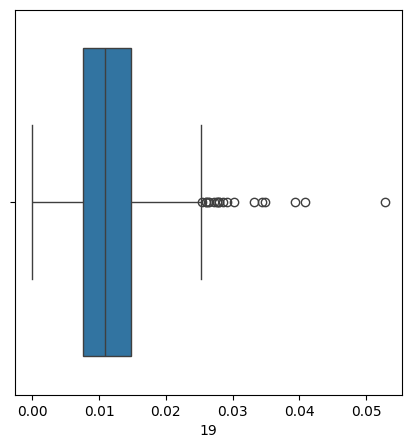

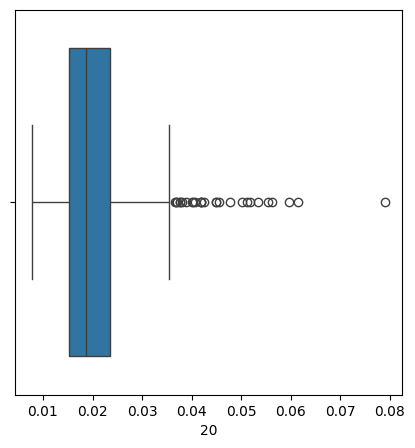

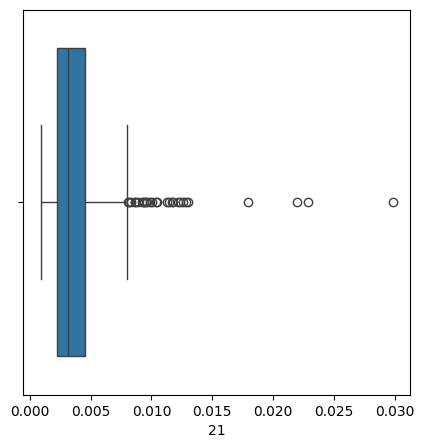

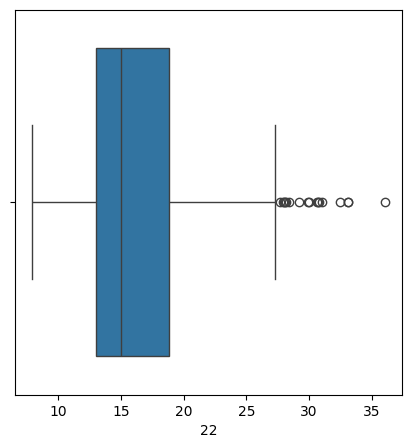

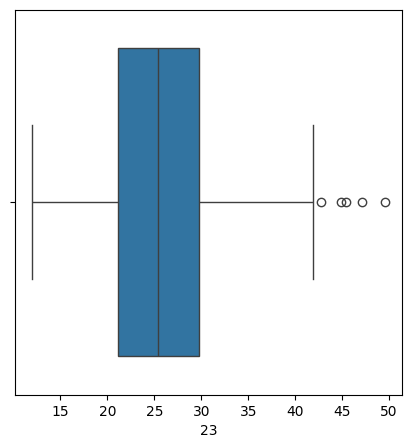

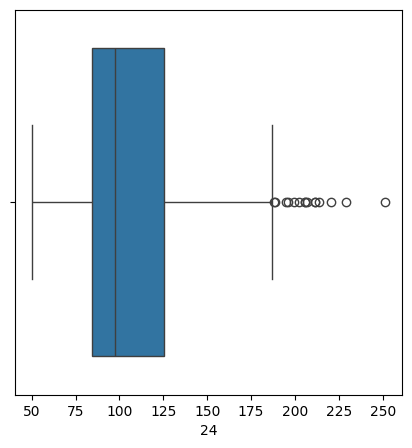

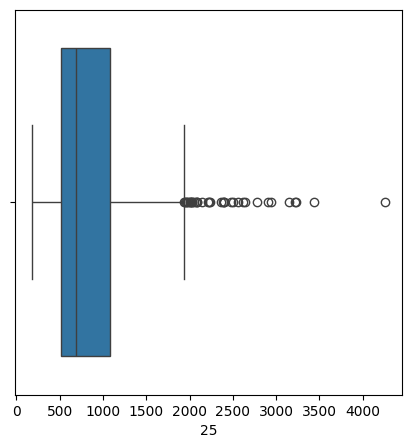

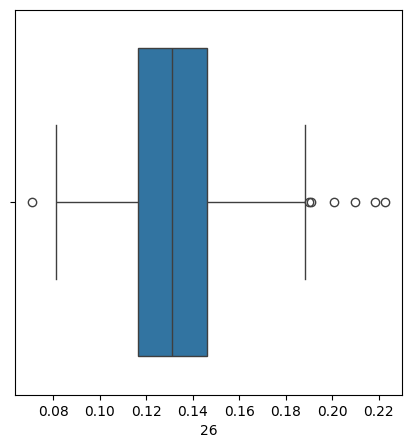

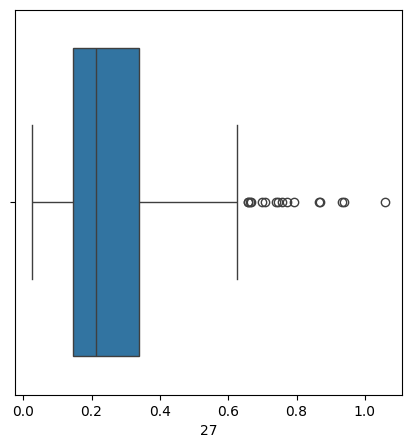

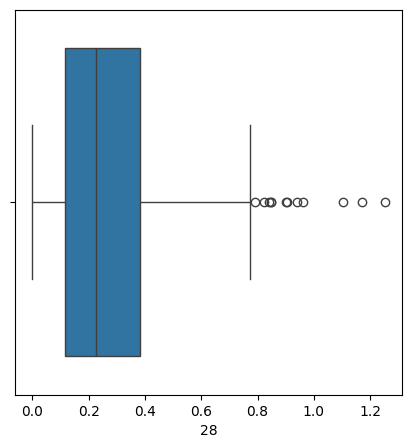

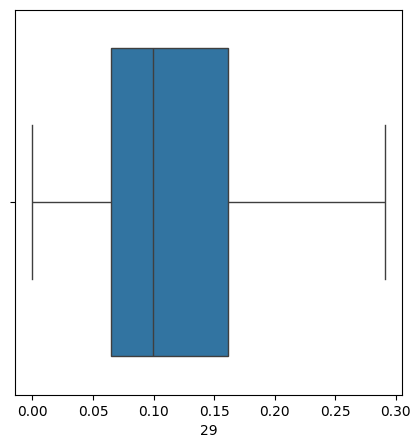

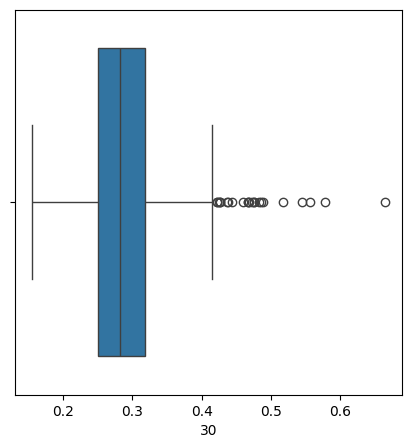

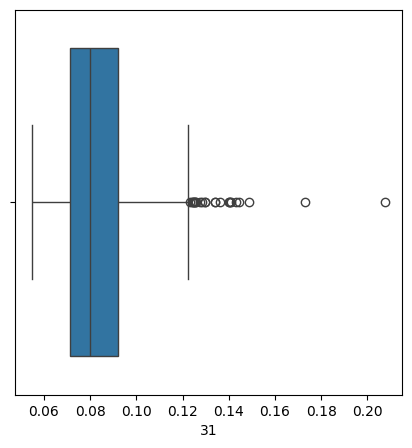

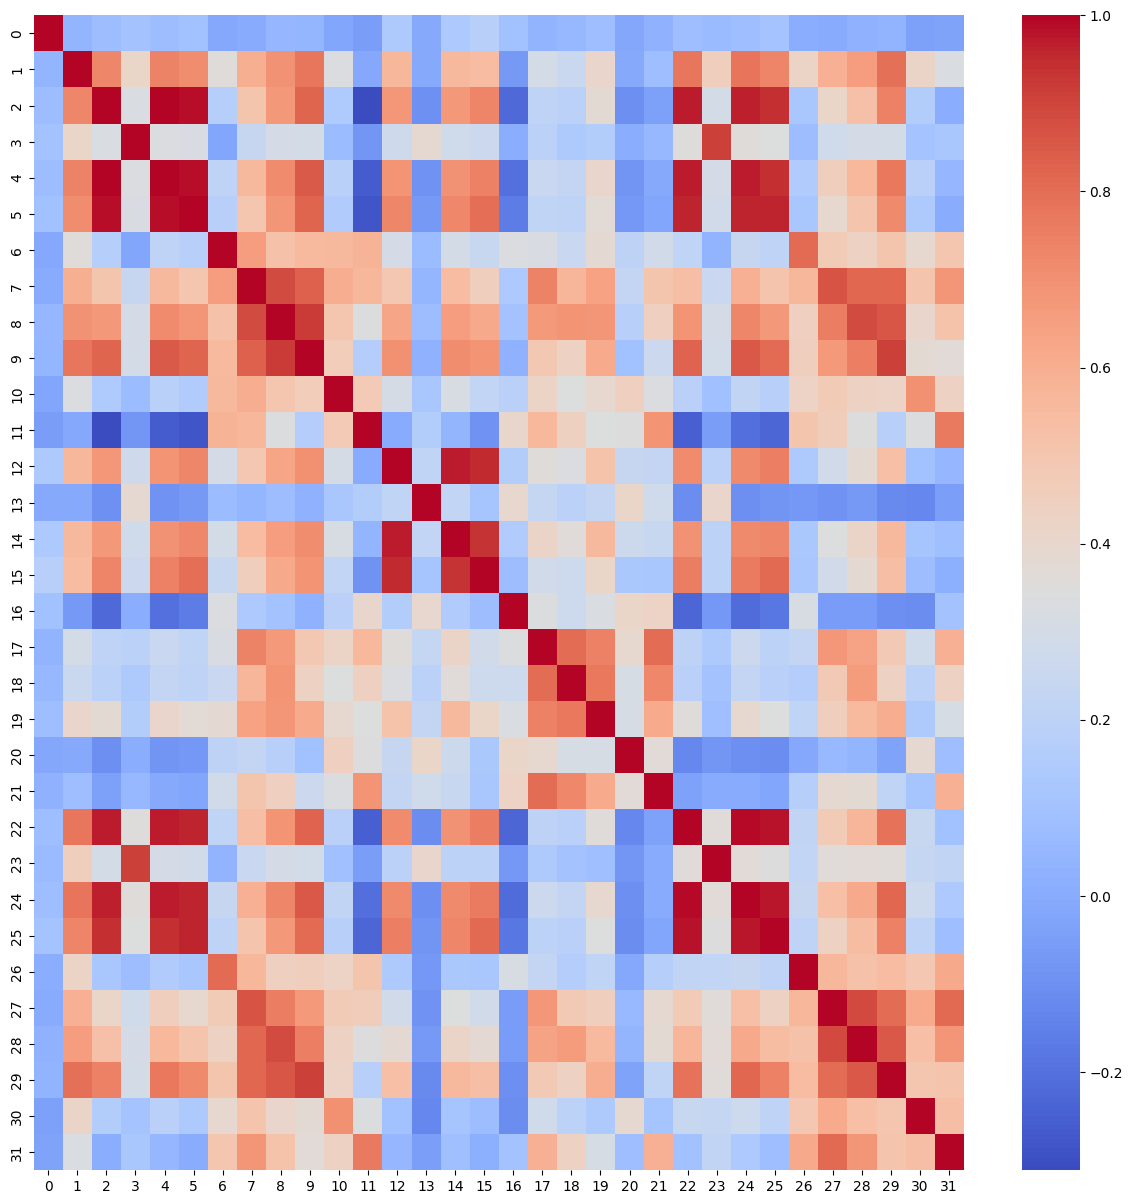

In [9]:

column=df.columns
EDA(df)

for col in column:
    histogram(col)
for col in column:
    outliers_detection(col)

label_encoding(df)

corr_analysis(df)

x=df.drop(columns=[0,1])
y=df[1]
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)



In [10]:
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

## Model Evaluation

In [11]:
def evaluation(actual ,predicted):
    print("\nAccuracy Score :  ",accuracy_score(actual,predicted))
    print("\nRecall score : ",recall_score(actual,predicted))
    print("\nF1  Score : ",f1_score(actual,predicted))
    print("\nPrecision score : ",precision_score(actual,predicted))
    print("\nConfusion Matrix :\n ",confusion_matrix(actual,predicted))
    

## 5-fold cross validation

In [12]:
def k_fold_validation(model,x,y):
    scores = cross_val_score(model, x, y, cv=5,scoring='accuracy')
    print("Cross validation Scores : ",scores)
    print("Mean : ",scores.mean())

## Grid Search

In [112]:
def grid_search(model,paramGrid,x,y):
    grid=GridSearchCV(estimator=model,param_grid=paramGrid,cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),scoring='accuracy',n_jobs=-1,error_score='raise')

    grid.fit(x,y)

    print(grid.best_estimator_)
    print(grid.best_params_)
    print(grid.best_score_)

    return grid.best_estimator_

## PCA

In [14]:
pca = PCA(n_components=0.95)

x_pca_train = pca.fit_transform(x_train_scaled)
x_test_pca =pca.transform(x_test_scaled)
print("Original Features :", x.shape[1])
print("Reduced Features :", x_pca_train.shape[1])

print("Explained Variance Ratio:",pca.explained_variance_ratio_)

print("Total Variance Retained:",sum(pca.explained_variance_ratio_))

Original Features : 30
Reduced Features : 10
Explained Variance Ratio: [0.44593522 0.18545255 0.09584641 0.06593768 0.05622286 0.03988488
 0.02214493 0.01614006 0.01284789 0.01165661]
Total Variance Retained: 0.9520691014391005


## Scree plot

In [173]:
def screePlot(pca):
    
    plt.figure(figsize=(5,5))
    cumulativeVariance=np.cumsum(pca.explained_variance_ratio_)
    plt.plot(range(1,len(cumulativeVariance)+1),cumulativeVariance,marker='o')
    plt.xlabel('Number of Componenets')
    plt.ylabel('Percentage of Variance')
    plt.savefig("C:/Users/DHARSHINI/Downloads/scree_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

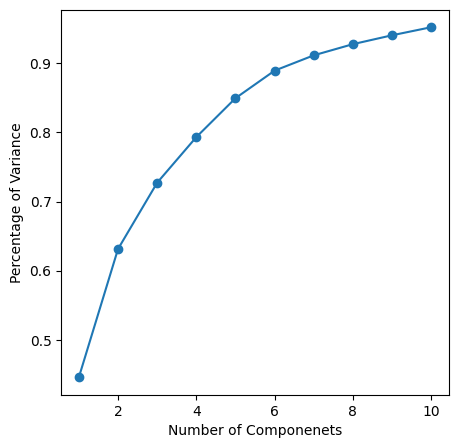

In [174]:
screePlot(pca)

## ROC curve

In [201]:
def ROC_CURVE(fpr,tpr,thresholds):
    plt.figure(figsize=(8,6))

    plt.plot(fpr,tpr,label=f'Logistic Regression (AUC = {auc:.3f})')
    
    plt.plot([0,1],[0,1],linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.savefig("C:/Users/DHARSHINI/Downloads/stacking_pca.png", dpi=300, bbox_inches="tight")
    plt.show()

## Logistic Regression without PCA

In [18]:
model=LogisticRegression(class_weight='balanced',max_iter=10000)
param_grid={'C':[0.01,0.1,1,10]}
best_model=grid_search(model,param_grid,x_train_scaled,y_train)


LogisticRegression(C=0.1, class_weight='balanced', max_iter=10000)
{'C': 0.1}
0.9758241758241759


In [19]:
k_fold_validation(best_model,x_train_scaled,y_train)

Cross validation Scores :  [0.96703297 1.         0.96703297 0.98901099 0.94505495]
Mean :  0.9736263736263737


In [20]:
predicted=best_model.predict(x_test_scaled)
evaluation(y_test,predicted)


Accuracy Score :   0.9912280701754386

Recall score :  0.9761904761904762

F1  Score :  0.9879518072289156

Precision score :  1.0

Confusion Matrix :
  [[72  0]
 [ 1 41]]


In [34]:
yprob = best_model.predict_proba(x_test_scaled)[:, 1]

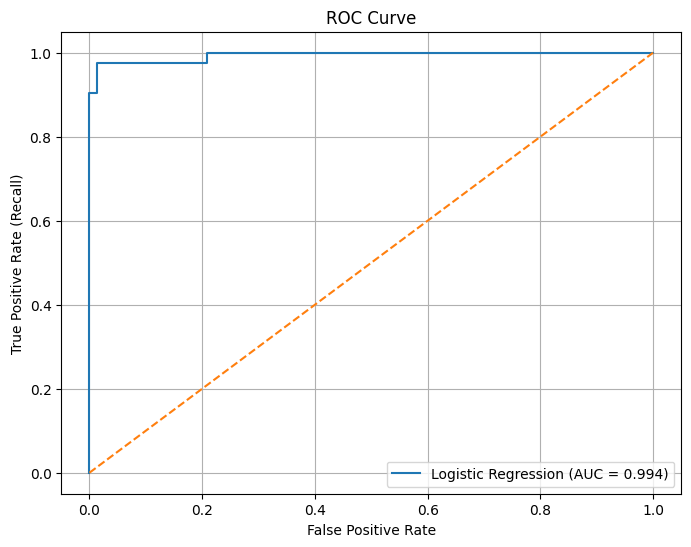

In [165]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## Logistic regression with PCA

In [21]:
pcaLogistic=grid_search(model,param_grid,x_pca_train,y_train)


LogisticRegression(C=0.1, class_weight='balanced', max_iter=10000)
{'C': 0.1}
0.9780219780219781


In [22]:
k_fold_validation(pcaLogistic,x_pca_train,y_train)

Cross validation Scores :  [0.96703297 1.         0.96703297 0.98901099 0.94505495]
Mean :  0.9736263736263737


In [23]:
pcaLogistic_predicted=pcaLogistic.predict(x_test_pca)
evaluation(y_test,pcaLogistic_predicted)


Accuracy Score :   0.9824561403508771

Recall score :  0.9523809523809523

F1  Score :  0.975609756097561

Precision score :  1.0

Confusion Matrix :
  [[72  0]
 [ 2 40]]


In [29]:
yprob = pcaLogistic.predict_proba(x_test_pca)[:, 1]

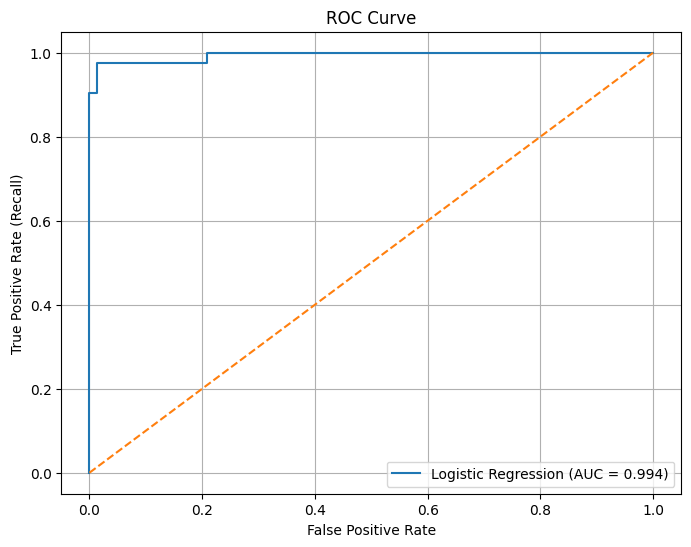

In [167]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)


## Support vector Machine

In [25]:
svm = SVC()

param_grid = {
    'C':[0.01,0.1,1,10,100],
    'kernel':['linear','rbf'],
    'gamma':['scale','auto']
}

best_svm = grid_search(
    svm,
    param_grid,
    x_train_scaled,
    y_train
)

SVC(C=10)
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
0.9758241758241759


In [26]:
k_fold_validation(
    best_svm,
    x_train_scaled,
    y_train
)

Cross validation Scores :  [0.97802198 1.         0.96703297 0.97802198 0.94505495]
Mean :  0.9736263736263737


In [37]:
svm_predicted = best_svm.predict(
    x_test_scaled
)

evaluation(
    y_test,
    svm_predicted
)


Accuracy Score :   0.9736842105263158

Recall score :  0.9285714285714286

F1  Score :  0.9629629629629629

Precision score :  1.0

Confusion Matrix :
  [[72  0]
 [ 3 39]]


In [28]:
best_pca_svn=grid_search(svm,param_grid,x_pca_train,y_train)

SVC(C=10)
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
0.9714285714285715


In [34]:
k_fold_validation(
    best_pca_svm,
    x_pca_train,
    y_train
)

Cross validation Scores :  [0.95604396 1.         0.96703297 0.97802198 0.9010989 ]
Mean :  0.9604395604395606


In [36]:
svm_pca_predicted = best_pca_svm.predict(
   x_test_pca)
evaluation(
    y_test,
    svm_pca_predicted
)


Accuracy Score :   0.9649122807017544

Recall score :  0.9285714285714286

F1  Score :  0.9512195121951219

Precision score :  0.975

Confusion Matrix :
  [[71  1]
 [ 3 39]]


## Naive Bayes 

In [37]:
GB=GaussianNB()

param_grid={'var_smoothing':[1e-9,1e-8,1e-7,1e-6]}

## Naive Bayes without PCA

In [38]:
best_NB=grid_search(GB,param_grid,x_train_scaled,y_train)

GaussianNB()
{'var_smoothing': 1e-09}
0.9384615384615385


In [39]:
k_fold_validation(best_NB,x_train_scaled,y_train)

Cross validation Scores :  [0.92307692 0.98901099 0.92307692 0.92307692 0.93406593]
Mean :  0.9384615384615385


In [40]:
NB_precited=best_NB.predict(x_test_scaled)
evaluation(y_test,NB_precited)


Accuracy Score :   0.9210526315789473

Recall score :  0.8571428571428571

F1  Score :  0.8888888888888888

Precision score :  0.9230769230769231

Confusion Matrix :
  [[69  3]
 [ 6 36]]


In [42]:
yprob = best_NB.predict_proba(x_test_scaled)[:, 1]

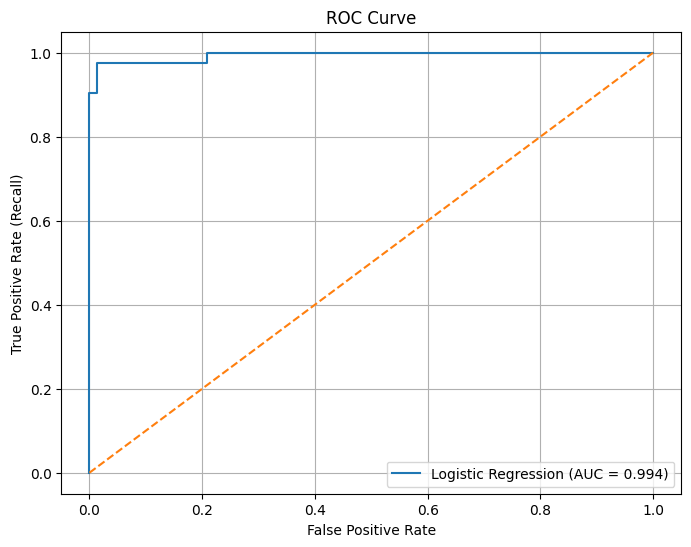

In [170]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## Naive bayes with PCA

In [44]:
best_NB_pca=grid_search(GB,param_grid,x_pca_train,y_train)

GaussianNB()
{'var_smoothing': 1e-09}
0.9120879120879121


In [45]:
k_fold_validation(best_NB_pca,x_pca_train,y_train)

Cross validation Scores :  [0.9010989  0.97802198 0.93406593 0.9010989  0.89010989]
Mean :  0.9208791208791208


In [46]:
NB_predicted_PCA=best_NB_pca.predict(x_test_pca)
evaluation(y_test,NB_predicted_PCA)


Accuracy Score :   0.8947368421052632

Recall score :  0.8571428571428571

F1  Score :  0.8571428571428571

Precision score :  0.8571428571428571

Confusion Matrix :
  [[66  6]
 [ 6 36]]


In [47]:
yprob = best_NB_pca.predict_proba(x_test_pca)[:, 1]

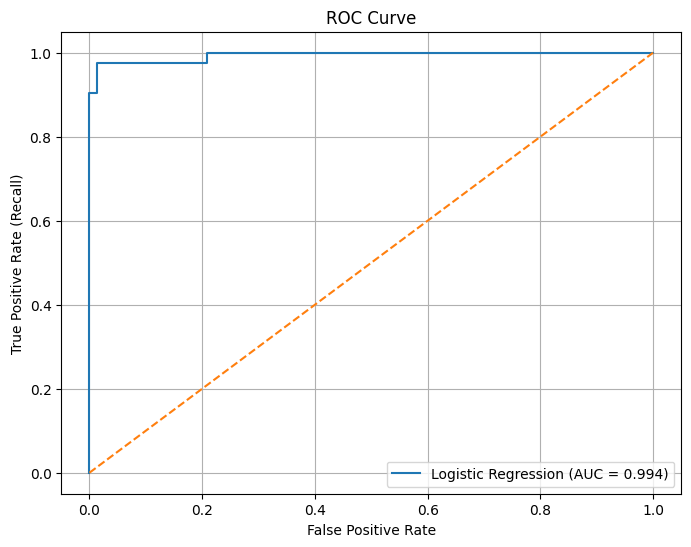

In [172]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## k-Nearest Neighbors (KNN)

In [49]:
knn=KNeighborsClassifier()

param_grid = {
    'n_neighbors':[3,5,7,9,11],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}

##  KNN wihtout PCA

In [50]:
best_KNN=grid_search(knn,param_grid,x_train_scaled,y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=3)
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
0.9758241758241759


In [51]:
k_fold_validation(best_KNN,x_train_scaled,y_train)

Cross validation Scores :  [0.96703297 1.         0.94505495 0.97802198 0.94505495]
Mean :  0.9670329670329672


In [52]:
KNN_predicted=best_KNN.predict(x_test_scaled)
evaluation(y_test,KNN_predicted)


Accuracy Score :   0.9649122807017544

Recall score :  0.9047619047619048

F1  Score :  0.95

Precision score :  1.0

Confusion Matrix :
  [[72  0]
 [ 4 38]]


In [53]:
yprob = best_KNN.predict_proba(x_test_scaled)[:, 1]

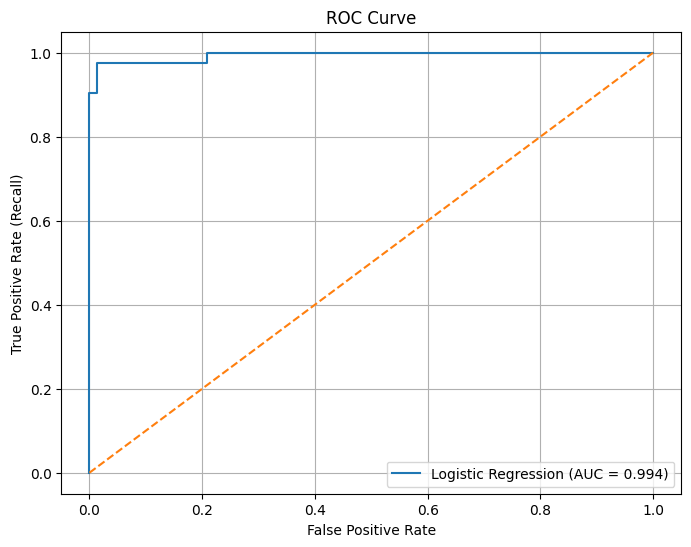

In [176]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## KNN with PCA

In [55]:
KNN_PCA=grid_search(knn,param_grid,x_pca_train,y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
0.9714285714285713


In [56]:
k_fold_validation(KNN_PCA,x_pca_train,y_train)

Cross validation Scores :  [0.96703297 1.         0.94505495 0.96703297 0.94505495]
Mean :  0.964835164835165


In [57]:
KNN_predicted_pca=KNN_PCA.predict(x_test_pca)
evaluation(y_test,KNN_predicted_pca)


Accuracy Score :   0.9473684210526315

Recall score :  0.8809523809523809

F1  Score :  0.925

Precision score :  0.9736842105263158

Confusion Matrix :
  [[71  1]
 [ 5 37]]


In [58]:
yprob = KNN_PCA.predict_proba(x_test_pca)[:, 1]

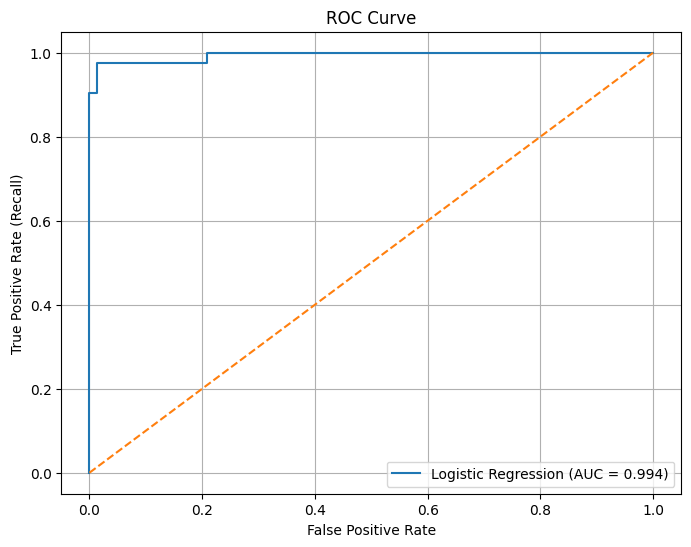

In [178]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## Decision Tree

In [60]:
decisiontree=DecisionTreeClassifier()
param_grid = {
    'criterion':['gini','entropy'],
    'max_depth':[3,5,7,10,None]}

## Decision tree wihtout PCA

In [61]:
best_dt=grid_search(decisiontree,param_grid,x_train_scaled,y_train)

DecisionTreeClassifier(criterion='entropy')
{'criterion': 'entropy', 'max_depth': None}
0.9296703296703297


In [62]:
k_fold_validation(best_dt,x_train_scaled,y_train)

Cross validation Scores :  [0.98901099 0.95604396 0.92307692 0.93406593 0.9010989 ]
Mean :  0.9406593406593409


In [63]:
dt_predicted=best_dt.predict(x_test_scaled)
evaluation(y_test,dt_predicted)


Accuracy Score :   0.956140350877193

Recall score :  0.8809523809523809

F1  Score :  0.9367088607594937

Precision score :  1.0

Confusion Matrix :
  [[72  0]
 [ 5 37]]


In [64]:
yprob = best_dt.predict_proba(x_test_scaled)[:, 1]

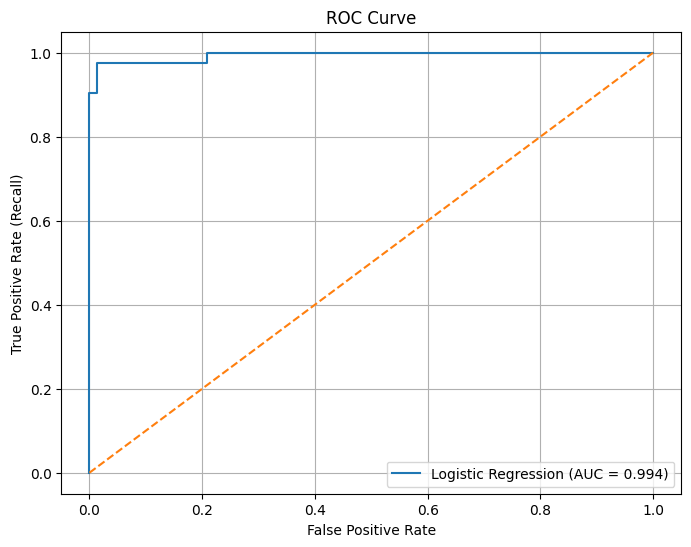

In [180]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## Decision tree with PCA

In [66]:
dt_pca=grid_search(decisiontree,param_grid,x_pca_train,y_train)

DecisionTreeClassifier(criterion='entropy')
{'criterion': 'entropy', 'max_depth': None}
0.9516483516483516


In [67]:
k_fold_validation(dt_pca,x_pca_train,y_train)

Cross validation Scores :  [0.87912088 0.96703297 0.92307692 0.97802198 0.9010989 ]
Mean :  0.9296703296703297


In [68]:
dt_pca_predicted=dt_pca.predict(x_test_pca)
evaluation(y_test,dt_pca_predicted)


Accuracy Score :   0.9385964912280702

Recall score :  0.9047619047619048

F1  Score :  0.9156626506024096

Precision score :  0.926829268292683

Confusion Matrix :
  [[69  3]
 [ 4 38]]


In [74]:
yprob = dt_pca.predict_proba(x_test_pca)[:, 1]

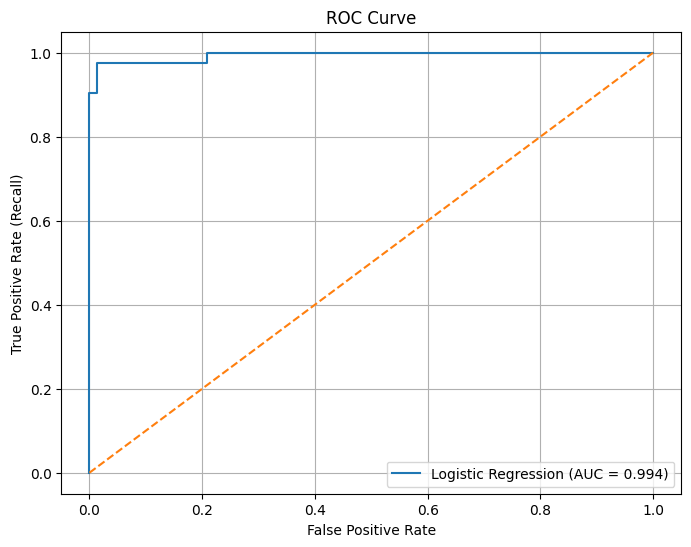

In [182]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## random Forest

In [77]:
rf=RandomForestClassifier()
param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[None,5,10,15]
}


## Random Forest without PCA

In [78]:
best_rf=grid_search(rf,param_grid,x_train_scaled,y_train)

RandomForestClassifier(max_depth=10, n_estimators=50)
{'max_depth': 10, 'n_estimators': 50}
0.9648351648351647


In [79]:
k_fold_validation(best_rf,x_train_scaled,y_train)

Cross validation Scores :  [0.98901099 0.98901099 0.93406593 0.98901099 0.93406593]
Mean :  0.9670329670329672


In [80]:
rf_predicted=best_rf.predict(x_test_scaled)
evaluation(y_test,rf_predicted)


Accuracy Score :   0.9736842105263158

Recall score :  0.9285714285714286

F1  Score :  0.9629629629629629

Precision score :  1.0

Confusion Matrix :
  [[72  0]
 [ 3 39]]


In [81]:
yprob = best_rf.predict_proba(x_test_scaled)[:, 1]

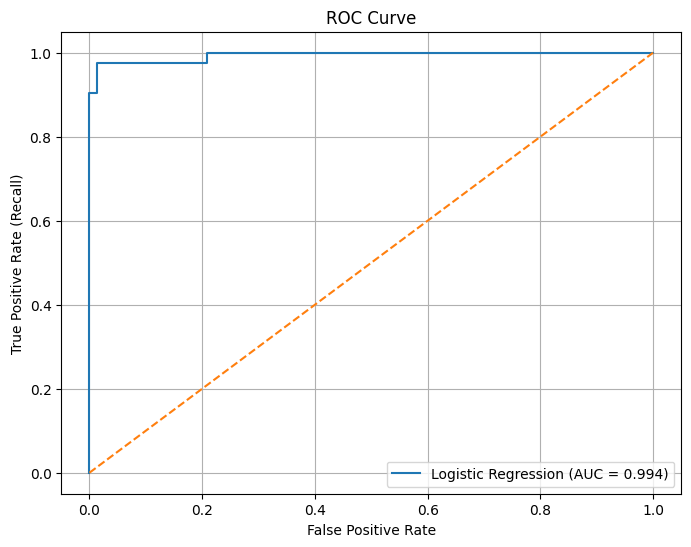

In [184]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## Random Forest with PCA

In [84]:
rf_pca=grid_search(rf,param_grid,x_pca_train,y_train)

RandomForestClassifier(max_depth=15, n_estimators=50)
{'max_depth': 15, 'n_estimators': 50}
0.9604395604395606


In [85]:
k_fold_validation(rf_pca,x_pca_train,y_train)

Cross validation Scores :  [0.9010989  1.         0.94505495 0.96703297 0.96703297]
Mean :  0.956043956043956


In [86]:
rf_pca_predicted=rf_pca.predict(x_test_pca)
evaluation(y_test,rf_pca_predicted)


Accuracy Score :   0.9385964912280702

Recall score :  0.9047619047619048

F1  Score :  0.9156626506024096

Precision score :  0.926829268292683

Confusion Matrix :
  [[69  3]
 [ 4 38]]


In [87]:
yprob = rf_pca.predict_proba(x_test_pca)[:, 1]

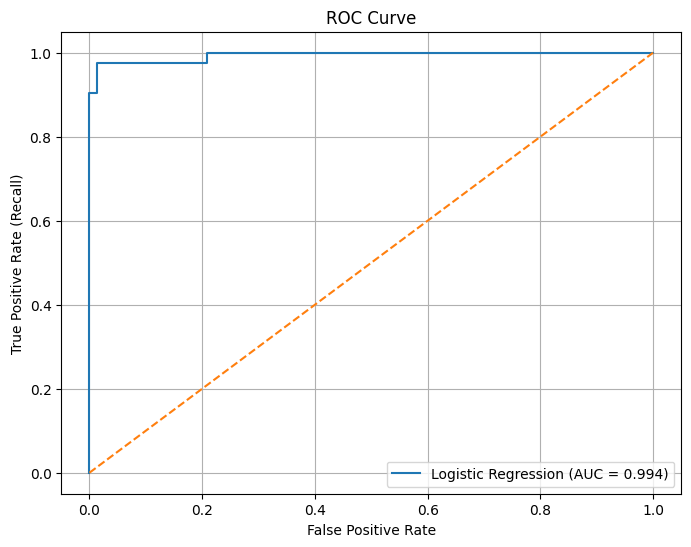

In [186]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## AdaBoost with PCA

In [89]:
ada=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),random_state=42)

param_grid={'n_estimators':[10,20,100],'learning_rate':[0.01,0.1,0.5,1.0]}

    

In [90]:
best_ada=grid_search(ada,param_grid,x_train_scaled,y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=100, random_state=42)
{'learning_rate': 0.5, 'n_estimators': 100}
0.9714285714285715


In [91]:
k_fold_validation(best_ada,x_train_scaled,y_train)

Cross validation Scores :  [0.98901099 0.98901099 0.92307692 0.96703297 0.91208791]
Mean :  0.9560439560439562


In [92]:
ada_predicted=best_ada.predict(x_test_scaled)
evaluation(y_test,ada_predicted)


Accuracy Score :   0.9736842105263158

Recall score :  0.9285714285714286

F1  Score :  0.9629629629629629

Precision score :  1.0

Confusion Matrix :
  [[72  0]
 [ 3 39]]


In [93]:
yprob = best_ada.predict_proba(x_test_scaled)[:, 1]

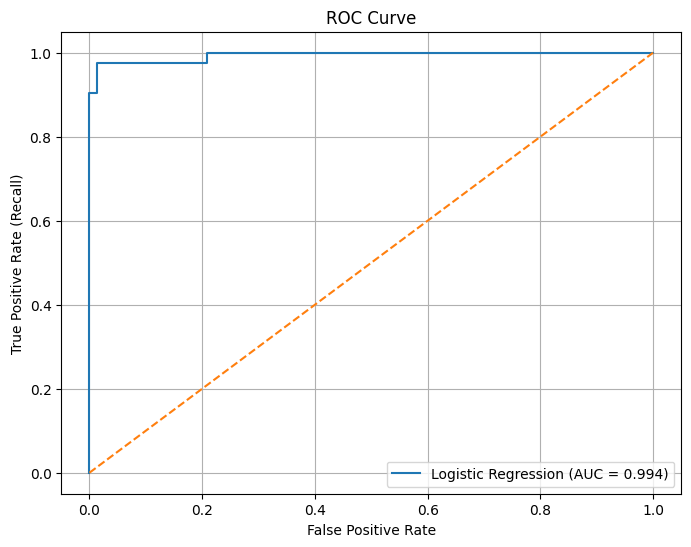

In [188]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## AdaBoost with PCA

In [95]:
best_ada_pca=grid_search(ada,param_grid,x_pca_train,y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=100, random_state=42)
{'learning_rate': 0.5, 'n_estimators': 100}
0.9714285714285713


In [96]:
k_fold_validation(best_ada_pca,x_pca_train,y_train)

Cross validation Scores :  [0.93406593 1.         0.95604396 0.97802198 0.94505495]
Mean :  0.9626373626373625


In [97]:
ada_pca_predict=best_ada_pca.predict(x_test_pca)
evaluation(y_test,ada_pca_predict)


Accuracy Score :   0.9473684210526315

Recall score :  0.8809523809523809

F1  Score :  0.925

Precision score :  0.9736842105263158

Confusion Matrix :
  [[71  1]
 [ 5 37]]


In [98]:
yprob = best_ada_pca.predict_proba(x_test_pca)[:, 1]

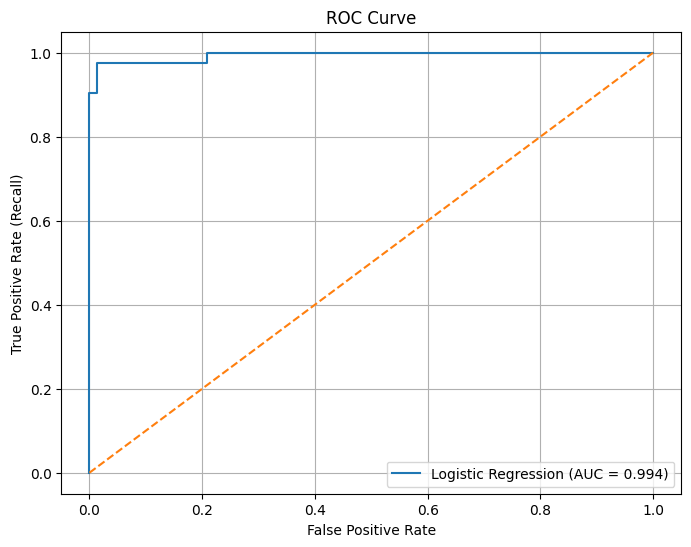

In [190]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## Gradient Boosting Classifier without PCA

In [107]:
gb=GradientBoostingClassifier(random_state=42)

param_grid = {'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.5],'max_depth':[1,3,5]}


In [108]:
best_gb=grid_search(gb,param_grid,x_train_scaled,y_train)

GradientBoostingClassifier(learning_rate=0.5, max_depth=1, n_estimators=200,
                           random_state=42)
{'learning_rate': 0.5, 'max_depth': 1, 'n_estimators': 200}
0.9802197802197803


In [109]:
k_fold_validation(best_gb,x_train_scaled,y_train)

Cross validation Scores :  [0.97802198 1.         0.93406593 0.96703297 0.92307692]
Mean :  0.9604395604395606


In [113]:
gb_predicted=best_gb.predict(x_test_scaled)
evaluation(y_test,gb_predicted)


Accuracy Score :   0.9736842105263158

Recall score :  0.9285714285714286

F1  Score :  0.9629629629629629

Precision score :  1.0

Confusion Matrix :
  [[72  0]
 [ 3 39]]


In [115]:
yprob = best_gb.predict_proba(x_test_scaled)[:, 1]

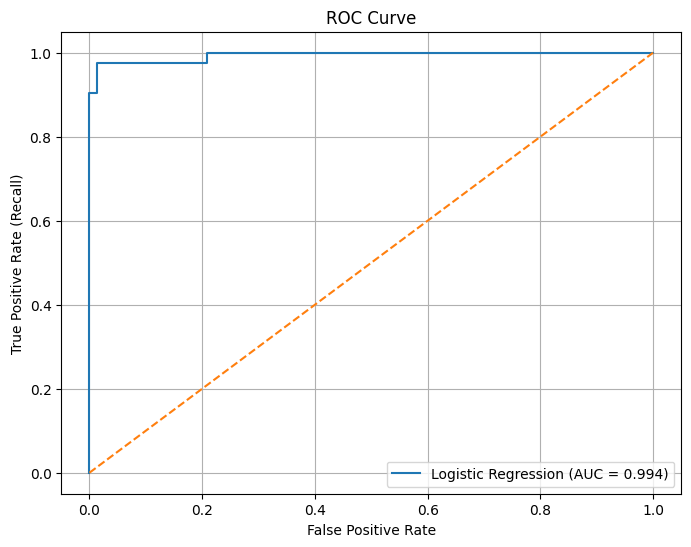

In [196]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## Gradient Boosting Classifier with PCA

In [117]:
best_gb_pca=grid_search(gb,param_grid,x_pca_train,y_train)

GradientBoostingClassifier(learning_rate=0.5, n_estimators=50, random_state=42)
{'learning_rate': 0.5, 'max_depth': 3, 'n_estimators': 50}
0.9648351648351647


In [118]:
k_fold_validation(best_gb_pca,x_pca_train,y_train)

Cross validation Scores :  [0.87912088 0.97802198 0.92307692 0.98901099 0.93406593]
Mean :  0.9406593406593406


In [119]:
gb_pca_predicted=best_gb_pca.predict(x_test_pca)
evaluation(y_test,gb_pca_predicted)


Accuracy Score :   0.9473684210526315

Recall score :  0.9047619047619048

F1  Score :  0.926829268292683

Precision score :  0.95

Confusion Matrix :
  [[70  2]
 [ 4 38]]


In [121]:
yprob = best_gb_pca.predict_proba(x_test_pca)[:, 1]

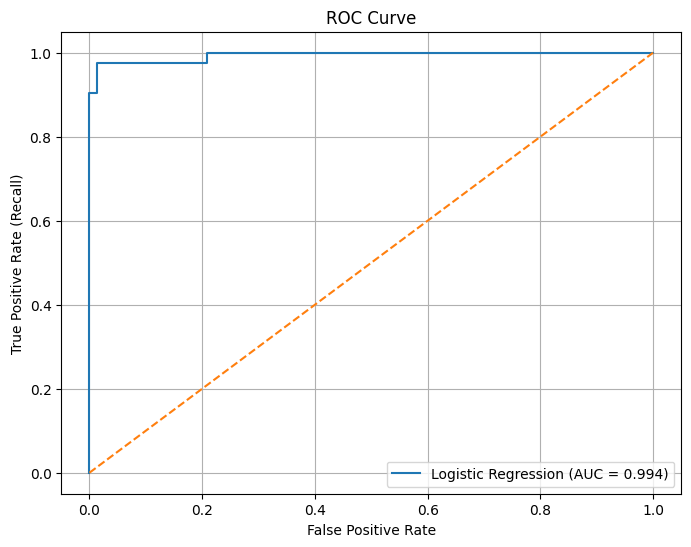

In [194]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## XGBoost without PCA

In [124]:
xgb=XGBClassifier(random_state=42,eval_metric='logloss')
param_grid = {'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3],'max_depth':[3,5,7]}

In [125]:
best_xg=grid_search(xgb,param_grid,x_train_scaled,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
0.9714285714285715


In [126]:
k_fold_validation(xgb,x_train_scaled,y_train)

Cross validation Scores :  [0.97802198 0.98901099 0.93406593 1.         0.91208791]
Mean :  0.9626373626373628


In [127]:
xgb_predicted = best_xg.predict(
    x_test_scaled
)
evaluation(
    y_test,
    xgb_predicted
)


Accuracy Score :   0.9649122807017544

Recall score :  0.9047619047619048

F1  Score :  0.95

Precision score :  1.0

Confusion Matrix :
  [[72  0]
 [ 4 38]]


In [128]:
yprob = best_xg.predict_proba(x_test_scaled)[:, 1]

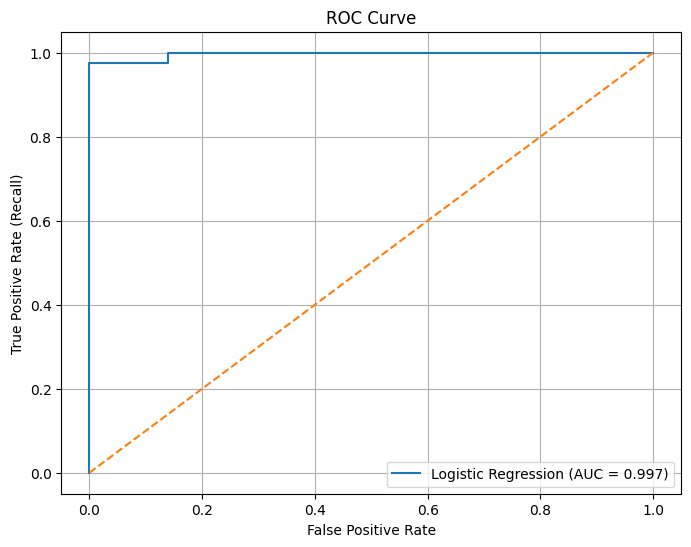

In [129]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## XGboost with PCA

In [131]:
best_xg_pca=grid_search(xgb,param_grid,x_pca_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)
{'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 50}
0.9692307692307691


In [132]:
k_fold_validation(best_xg_pca,x_pca_train,y_train)

Cross validation Scores :  [0.92307692 1.         0.94505495 0.97802198 0.95604396]
Mean :  0.9604395604395604


In [133]:
xgb_pca_predicted = best_xg_pca.predict(
    x_test_pca
)
evaluation(
    y_test,
    xgb_pca_predicted
)


Accuracy Score :   0.956140350877193

Recall score :  0.9047619047619048

F1  Score :  0.9382716049382716

Precision score :  0.9743589743589743

Confusion Matrix :
  [[71  1]
 [ 4 38]]


In [134]:
yprob = best_xg_pca.predict_proba(x_test_pca)[:, 1]

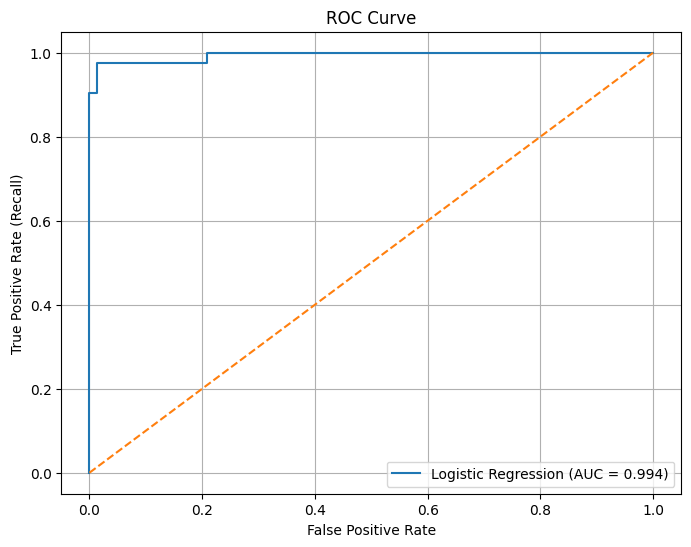

In [198]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## Stacking models

In [136]:

base_learners = [
    ('lr', LogisticRegression(max_iter=10000)),
    ('knn', KNeighborsClassifier(n_neighbors=3)),
    ('nb', GaussianNB()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
]


In [137]:
stack_model=StackingClassifier(estimators=base_learners,final_estimator=LogisticRegression(max_iter=10000),cv=5)

In [138]:
stack_model.fit(x_train_scaled,y_train)

StackingClassifier(cv=5,
                   estimators=[('lr', LogisticRegression(max_iter=10000)),
                               ('knn', KNeighborsClassifier(n_neighbors=3)),
                               ('nb', GaussianNB()),
                               ('rf', RandomForestClassifier(random_state=42))],
                   final_estimator=LogisticRegression(max_iter=10000))

In [139]:
k_fold_validation(stack_model,x_train_scaled,y_train)

Cross validation Scores :  [0.97802198 1.         0.94505495 0.97802198 0.95604396]
Mean :  0.9714285714285715


In [140]:
stack_predicted=stack_model.predict(x_test_scaled)
evaluation(y_test,stack_predicted)


Accuracy Score :   0.9824561403508771

Recall score :  0.9523809523809523

F1  Score :  0.975609756097561

Precision score :  1.0

Confusion Matrix :
  [[72  0]
 [ 2 40]]


In [141]:
yprob = stack_model.predict_proba(x_test_scaled)[:, 1]

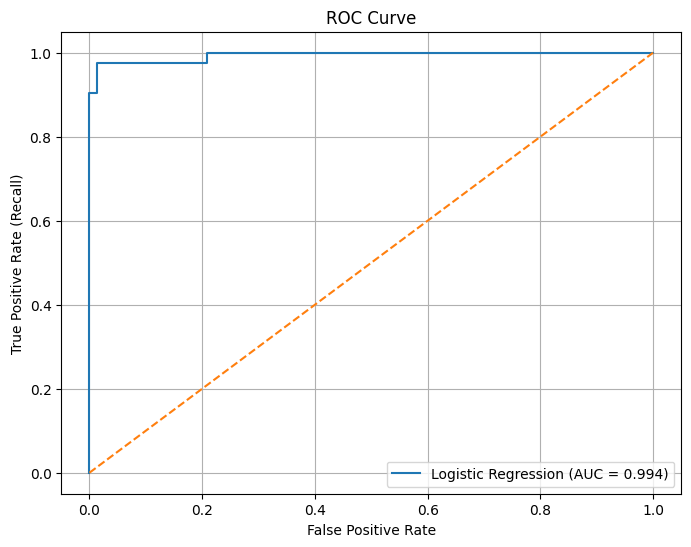

In [200]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)

## Stacking with pca

In [152]:
stack_model_pca=StackingClassifier(estimators=base_learners,final_estimator=LogisticRegression(max_iter=10000),cv=5)

In [157]:

stack_model_pca.fit(
    x_pca_train,
    y_train
)

StackingClassifier(cv=5,
                   estimators=[('lr', LogisticRegression(max_iter=10000)),
                               ('knn', KNeighborsClassifier(n_neighbors=3)),
                               ('nb', GaussianNB()),
                               ('rf', RandomForestClassifier(random_state=42))],
                   final_estimator=LogisticRegression(max_iter=10000))

In [158]:
k_fold_validation(stack_model_pca,x_pca_train,y_train)

Cross validation Scores :  [0.97802198 1.         0.95604396 0.98901099 0.95604396]
Mean :  0.9758241758241759


In [159]:
stack_pca_predicted = stack_model_pca.predict(x_test_pca)

evaluation(y_test,stack_pca_predicted)


Accuracy Score :   0.9649122807017544

Recall score :  0.9285714285714286

F1  Score :  0.9512195121951219

Precision score :  0.975

Confusion Matrix :
  [[71  1]
 [ 3 39]]


In [160]:
yprob = stack_model_pca.predict_proba(x_test_pca)[:, 1]

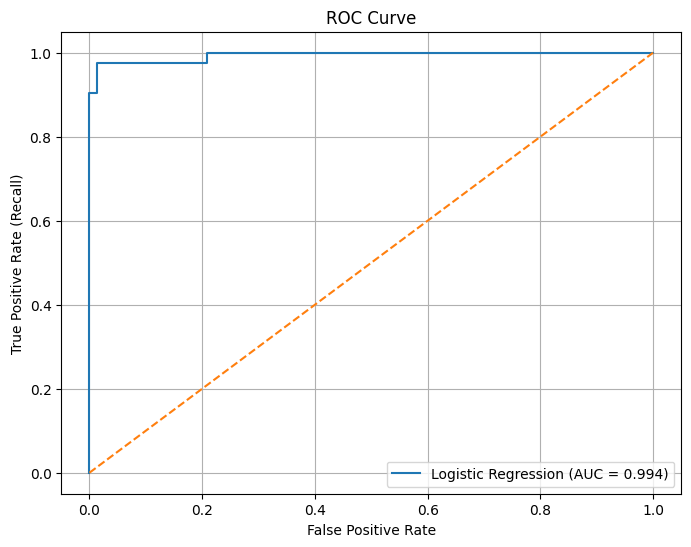

In [202]:
fpr, tpr, thresholds = roc_curve(y_test,yprob)
auc = roc_auc_score(y_test,yprob)
ROC_CURVE(fpr,tpr,thresholds)